# Bài 1

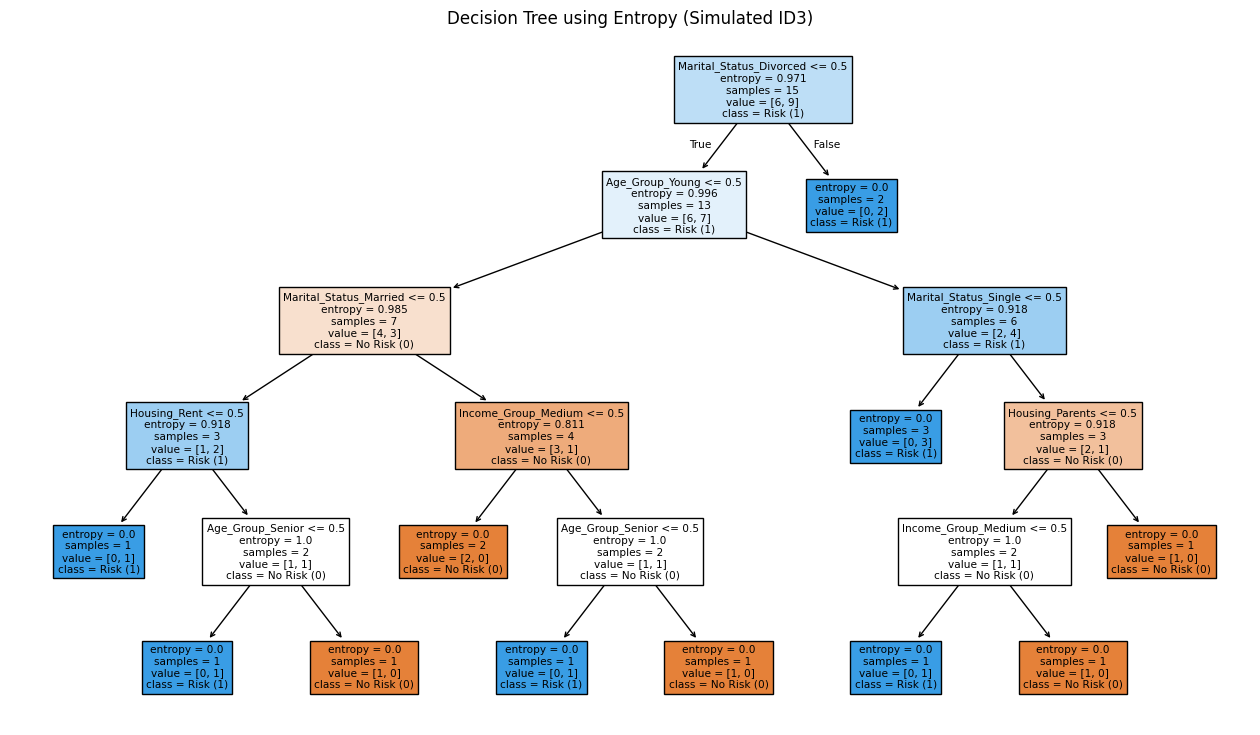

In [1]:
# ---------------------------------------
# A. Simulated ID3
# ---------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree

# 1. Dataset setup
data = {
    'Age': [25, 40, 35, 27, 31, 36, 48, 26, 33, 29, 38, 44, 42, 28, 30],
    'Marital_Status': [
        'Single', 'Married', 'Divorced', 'Married', 'Single',
        'Married', 'Single', 'Married', 'Divorced', 'Single',
        'Married', 'Single', 'Married', 'Single', 'Married'
    ],
    'Housing': [
        'Parents', 'Own', 'Rent', 'Parents', 'Rent',
        'Own', 'Rent', 'Rent', 'Parents', 'Rent',
        'Own', 'Own', 'Own', 'Rent', 'Parents'
    ],
    'Income': [
        7000000, 18000000, 12000000, 9000000, 6000000,
        8000000, 7000000, 8000000, 5000000, 10000000,
        15000000, 14000000, 10000000, 7000000, 6000000
    ],
    'Credit_Risk': [0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1]
}

df = pd.DataFrame(data)

# 2. Discretize continuous variables
df['Age_Group'] = pd.cut(df['Age'], bins=[0, 30, 40, 100], labels=['Young', 'Middle', 'Senior'])
df['Income_Group'] = pd.cut(df['Income'], bins=[0, 7000000, 12000000, np.inf], labels=['Low', 'Medium', 'High'])

# 3. Features & Target
X = df[['Age_Group', 'Marital_Status', 'Housing', 'Income_Group']]
y = df['Credit_Risk']

X_encoded = pd.get_dummies(X)

# 4. Scikit-learn tree
model = DecisionTreeClassifier(criterion='entropy', random_state=42)
model.fit(X_encoded, y)

# 5. Visualization
plt.figure(figsize=(16, 9))
plot_tree(
    model,
    feature_names=X_encoded.columns.tolist(),
    class_names=['No Risk (0)', 'Risk (1)'],
    filled=True
)
plt.title("Decision Tree using Entropy (Simulated ID3)")
plt.show()

In [3]:
# ---------------------------------------
# B. ID3
# ---------------------------------------

# 1. Dataset setup (Binned values)
data = {
    'Age': ['Young', 'Senior', 'Middle', 'Young', 'Middle', 'Middle', 'Senior', 'Young', 'Middle', 'Young', 'Middle', 'Senior', 'Senior', 'Young', 'Young'],
    'Marital': ['Single', 'Married', 'Divorced', 'Married', 'Single', 'Married', 'Single', 'Married', 'Divorced', 'Single', 'Married', 'Single', 'Married', 'Single', 'Married'],
    'Housing': ['Parents', 'Own', 'Rent', 'Parents', 'Rent', 'Own', 'Rent', 'Rent', 'Parents', 'Rent', 'Own', 'Own', 'Own', 'Rent', 'Parents'],
    'Income': ['Low', 'High', 'Medium', 'Medium', 'Low', 'Medium', 'Low', 'Medium', 'Low', 'Medium', 'High', 'High', 'Medium', 'Low', 'Low'],
    'Credit_Risk': [0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1]
}

df = pd.DataFrame(data)

# 2. ID3 Algorithm
def calculate_entropy(target_col):
    values, counts = np.unique(target_col, return_counts=True)
    probabilities = counts / counts.sum()
    return -np.sum(probabilities * np.log2(probabilities))

def calculate_information_gain(data_subset, feature, target_name):
    total_entropy = calculate_entropy(data_subset[target_name])
    vals, counts = np.unique(data_subset[feature], return_counts=True)
    weighted_entropy = np.sum([
        (counts[i] / np.sum(counts)) * calculate_entropy(data_subset.where(data_subset[feature] == vals[i]).dropna()[target_name])
        for i in range(len(vals))
    ])
    return total_entropy - weighted_entropy

def id3(data_subset, original_data, features, target_name='Credit_Risk'):
    if len(np.unique(data_subset[target_name])) <= 1:
        return np.unique(data_subset[target_name])[0]
    elif len(data_subset) == 0:
        return np.unique(original_data[target_name])[np.argmax(np.unique(original_data[target_name], return_counts=True)[1])]
    elif len(features) == 0:
        return np.unique(data_subset[target_name])[np.argmax(np.unique(data_subset[target_name], return_counts=True)[1])]

    item_values = [calculate_information_gain(data_subset, feature, target_name) for feature in features]
    best_feature_index = np.argmax(item_values)
    best_feature = features[best_feature_index]

    tree_dict = {best_feature: {}}
    remaining_features = [f for f in features if f != best_feature]

    for val in np.unique(data_subset[best_feature]):
        sub_data = data_subset.where(data_subset[best_feature] == val).dropna()
        subtree = id3(sub_data, original_data, remaining_features, target_name)
        tree_dict[best_feature][val] = subtree

    return tree_dict

features_list = ['Age', 'Marital', 'Housing', 'Income']
tree = id3(df, df, features_list)

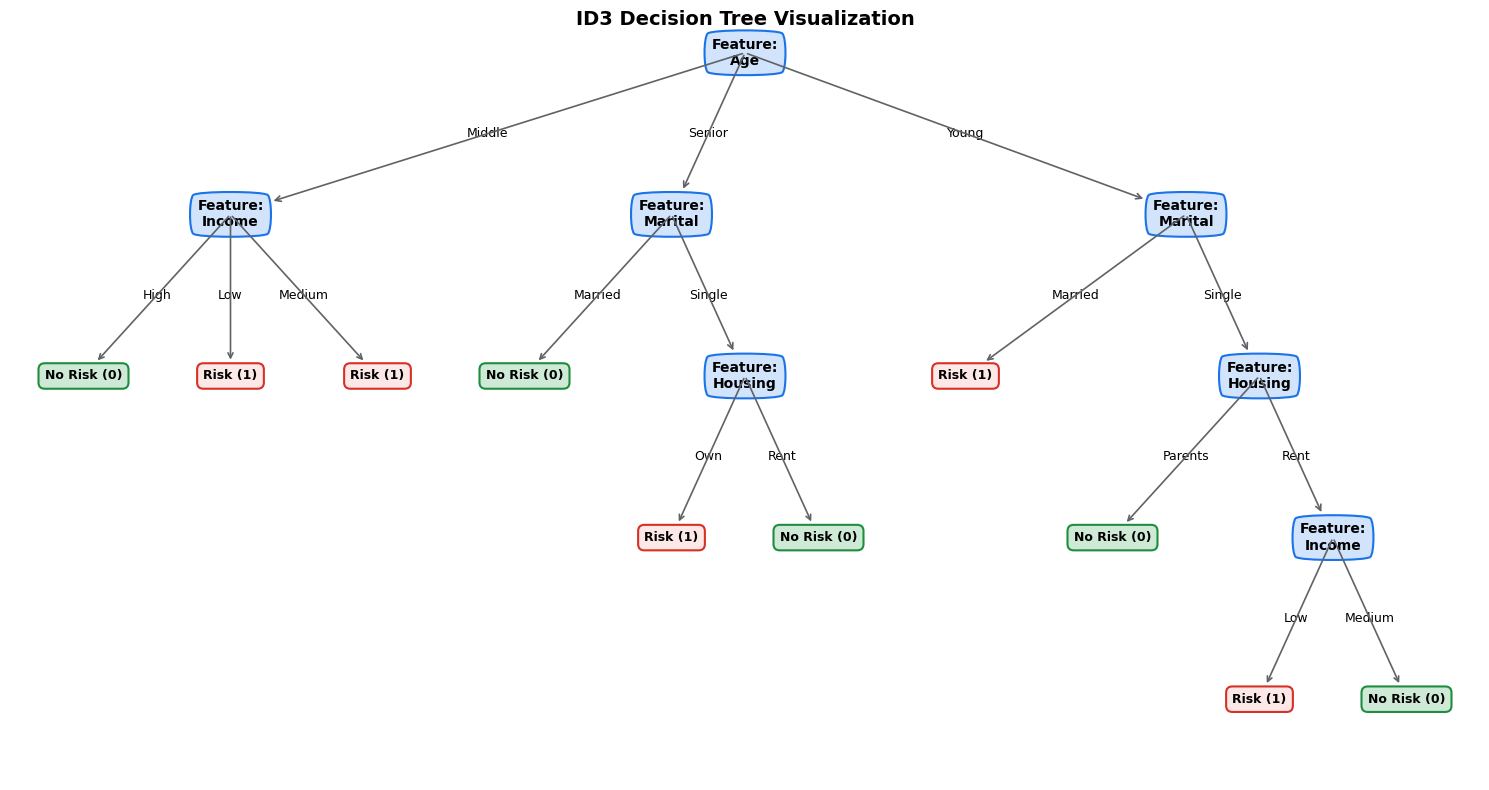

In [4]:
# 3. Layout calculation helpers
def get_num_leafs(my_tree):
    num_leafs = 0
    first_str = list(my_tree.keys())[0]
    second_dict = my_tree[first_str]
    for key in second_dict.keys():
        if isinstance(second_dict[key], dict):
            num_leafs += get_num_leafs(second_dict[key])
        else:
            num_leafs += 1
    return num_leafs

def get_tree_depth(my_tree):
    max_depth = 0
    first_str = list(my_tree.keys())[0]
    second_dict = my_tree[first_str]
    for key in second_dict.keys():
        if isinstance(second_dict[key], dict):
            this_depth = 1 + get_tree_depth(second_dict[key])
        else:
            this_depth = 1
        if this_depth > max_depth:
            max_depth = this_depth
    return max_depth
# 4. Matplotlib recursive plotting
decision_node_style = dict(boxstyle="round4,pad=0.6", fc="#d2e3fc", ec="#1a73e8", lw=1.5)
leaf_node_0_style   = dict(boxstyle="round,pad=0.5",  fc="#ceead6", ec="#1e8e3e", lw=1.5)
leaf_node_1_style   = dict(boxstyle="round,pad=0.5",  fc="#fce8e6", ec="#d93025", lw=1.5)
arrow_args = dict(arrowstyle="<-", color="#5f6368", lw=1.2)

def plot_mid_text(cntr_pt, parent_pt, txt_string, ax):
    x_mid = (parent_pt[0] - cntr_pt[0]) / 2.0 + cntr_pt[0]
    y_mid = (parent_pt[1] - cntr_pt[1]) / 2.0 + cntr_pt[1]
    ax.text(x_mid, y_mid, txt_string, va="center", ha="center", fontsize=9,
            bbox=dict(boxstyle="square,pad=0.2", fc="white", ec="none", alpha=0.8))

def plot_tree_recursive(my_tree, parent_pt, node_txt, ax, total_w, total_d, plot_state):
    num_leafs = get_num_leafs(my_tree)
    first_str = list(my_tree.keys())[0]
    cntr_pt = (plot_state['x_off'] + (1.0 + float(num_leafs)) / 2.0 / total_w, plot_state['y_off'])

    if node_txt:
        plot_mid_text(cntr_pt, parent_pt, node_txt, ax)

    ax.annotate(f"Feature:\n{first_str}", xy=parent_pt, xycoords='axes fraction',
                xytext=cntr_pt, textcoords='axes fraction',
                va="center", ha="center", bbox=decision_node_style,
                arrowprops=arrow_args if node_txt else None, fontsize=10, weight='bold')

    second_dict = my_tree[first_str]
    plot_state['y_off'] -= 1.0 / total_d

    for key in second_dict.keys():
        if isinstance(second_dict[key], dict):
            plot_tree_recursive(second_dict[key], cntr_pt, str(key), ax, total_w, total_d, plot_state)
        else:
            plot_state['x_off'] += 1.0 / total_w
            leaf_val = second_dict[key]
            lbl = f"No Risk (0)" if leaf_val == 0 else f"Risk (1)"
            st = leaf_node_0_style if leaf_val == 0 else leaf_node_1_style
            leaf_pt = (plot_state['x_off'], plot_state['y_off'])

            plot_mid_text(leaf_pt, cntr_pt, str(key), ax)
            ax.annotate(lbl, xy=cntr_pt, xycoords='axes fraction',
                        xytext=leaf_pt, textcoords='axes fraction',
                        va="center", ha="center", bbox=st,
                        arrowprops=arrow_args, fontsize=9, weight='bold')

    plot_state['y_off'] += 1.0 / total_d

def render_id3_tree(tree_dict):
    fig, ax = plt.subplots(figsize=(15, 8))
    ax.axis('off')

    total_w = float(get_num_leafs(tree_dict))
    total_d = float(get_tree_depth(tree_dict)) + 0.5
    plot_state = {'x_off': -0.5 / total_w, 'y_off': 1.0}

    plot_tree_recursive(tree_dict, (0.5, 1.0), '', ax, total_w, total_d, plot_state)
    plt.title("ID3 Decision Tree Visualization", fontsize=14, pad=20, weight='bold')
    plt.tight_layout()
    plt.show()

# 5. Display tree graph
render_id3_tree(tree)

# Bài 2

In [5]:
import pprint

# 1. Prepare dataset
data = {
    'age': [
        '<=30', '<=30', '31...40', '>40', '>40', '>40', '31...40',
        '<=30', '<=30', '>40', '<=30', '31...40', '31...40', '>40'
    ],
    'income': [
        'high', 'high', 'high', 'medium', 'low', 'low', 'low',
        'medium', 'low', 'medium', 'medium', 'medium', 'high', 'medium'
    ],
    'student': [
        'no', 'no', 'no', 'no', 'yes', 'yes', 'yes',
        'no', 'yes', 'yes', 'yes', 'no', 'yes', 'no'
    ],
    'credit_rating': [
        'fair', 'excellent', 'fair', 'fair', 'fair', 'excellent', 'excellent',
        'fair', 'fair', 'fair', 'excellent', 'excellent', 'fair', 'excellent'
    ],
    'buys_computer': [
        'no', 'no', 'yes', 'yes', 'yes', 'no', 'yes',
        'no', 'yes', 'yes', 'yes', 'yes', 'yes', 'no'
    ]
}

df = pd.DataFrame(data)

# 2. Functions
def calculate_entropy(target_col):
    values, counts = np.unique(target_col, return_counts=True)
    probabilities = counts / counts.sum()
    return -np.sum(probabilities * np.log2(probabilities))

def calculate_information_gain(data_subset, feature, target_name):
    total_entropy = calculate_entropy(data_subset[target_name])
    vals, counts = np.unique(data_subset[feature], return_counts=True)
    weighted_entropy = np.sum([
        (counts[i] / np.sum(counts)) * calculate_entropy(
            data_subset.where(data_subset[feature] == vals[i]).dropna()[target_name]
        )
        for i in range(len(vals))
    ])
    return total_entropy - weighted_entropy

# 3. ID3 recursive tree builder
def id3(data_subset, original_data, features, target_name='buys_computer'):
    # Base case 1: pure target labels
    if len(np.unique(data_subset[target_name])) <= 1:
        return np.unique(data_subset[target_name])[0]

    # Base case 2: empty subset
    elif len(data_subset) == 0:
        vals, counts = np.unique(original_data[target_name], return_counts=True)
        return vals[np.argmax(counts)]

    # Base case 3: no remaining features
    elif len(features) == 0:
        vals, counts = np.unique(data_subset[target_name], return_counts=True)
        return vals[np.argmax(counts)]

    # Information gain
    gains = [calculate_information_gain(data_subset, feature, target_name) for feature in features]
    best_feature_idx = np.argmax(gains)
    best_feature = features[best_feature_idx]

    tree = {best_feature: {}}
    remaining_features = [f for f in features if f != best_feature]

    for val in np.unique(data_subset[best_feature]):
        sub_data = data_subset.where(data_subset[best_feature] == val).dropna()
        subtree = id3(sub_data, original_data, remaining_features, target_name)
        tree[best_feature][val] = subtree

    return tree

features_list = ['age', 'income', 'student', 'credit_rating']
decision_tree = id3(df, df, features_list)

print("ID3 Decision Tree Structure:")
pprint.pprint(decision_tree)

ID3 Decision Tree Structure:
{'age': {'31...40': 'yes',
         '<=30': {'student': {'no': 'no', 'yes': 'yes'}},
         '>40': {'credit_rating': {'excellent': 'no', 'fair': 'yes'}}}}


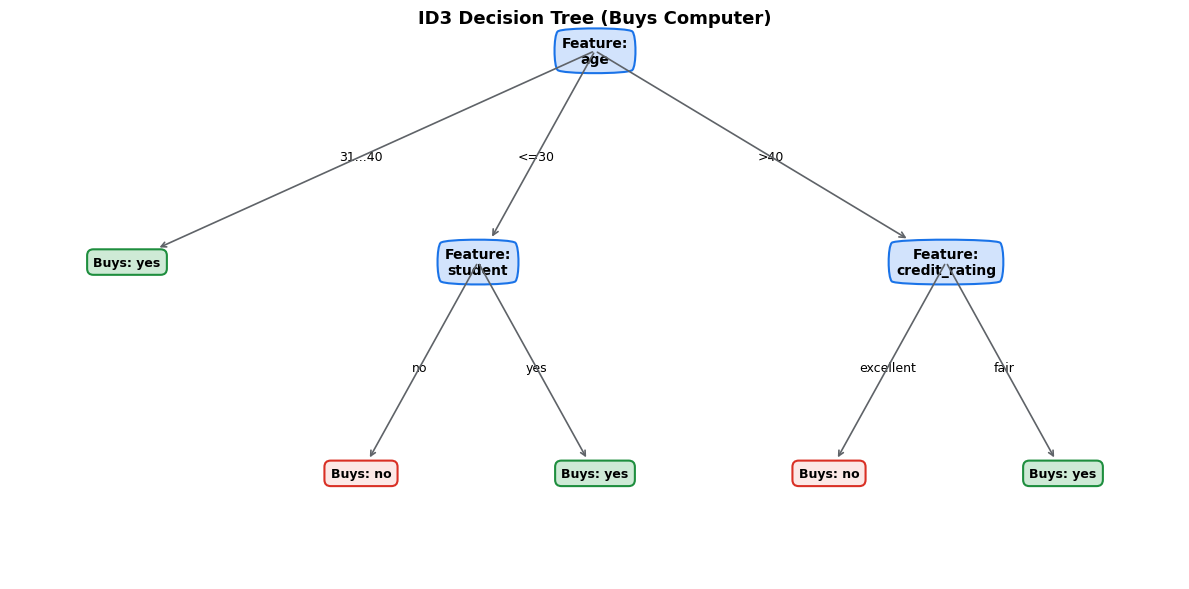

In [6]:
# 4. Matplotlib Tree Visualizer
def get_num_leafs(my_tree):
    num_leafs = 0
    first_str = list(my_tree.keys())[0]
    second_dict = my_tree[first_str]
    for key in second_dict.keys():
        if isinstance(second_dict[key], dict):
            num_leafs += get_num_leafs(second_dict[key])
        else:
            num_leafs += 1
    return num_leafs

def get_tree_depth(my_tree):
    max_depth = 0
    first_str = list(my_tree.keys())[0]
    second_dict = my_tree[first_str]
    for key in second_dict.keys():
        if isinstance(second_dict[key], dict):
            this_depth = 1 + get_tree_depth(second_dict[key])
        else:
            this_depth = 1
        if this_depth > max_depth:
            max_depth = this_depth
    return max_depth

decision_node_style = dict(boxstyle="round4,pad=0.6", fc="#d2e3fc", ec="#1a73e8", lw=1.5)
leaf_node_yes_style = dict(boxstyle="round,pad=0.5",  fc="#ceead6", ec="#1e8e3e", lw=1.5)
leaf_node_no_style  = dict(boxstyle="round,pad=0.5",  fc="#fce8e6", ec="#d93025", lw=1.5)
arrow_args = dict(arrowstyle="<-", color="#5f6368", lw=1.2)

def plot_mid_text(cntr_pt, parent_pt, txt_string, ax):
    x_mid = (parent_pt[0] - cntr_pt[0]) / 2.0 + cntr_pt[0]
    y_mid = (parent_pt[1] - cntr_pt[1]) / 2.0 + cntr_pt[1]
    ax.text(x_mid, y_mid, txt_string, va="center", ha="center", fontsize=9,
            bbox=dict(boxstyle="square,pad=0.2", fc="white", ec="none", alpha=0.85))

def plot_tree_recursive(my_tree, parent_pt, node_txt, ax, total_w, total_d, plot_state):
    num_leafs = get_num_leafs(my_tree)
    first_str = list(my_tree.keys())[0]
    cntr_pt = (plot_state['x_off'] + (1.0 + float(num_leafs)) / 2.0 / total_w, plot_state['y_off'])

    if node_txt:
        plot_mid_text(cntr_pt, parent_pt, node_txt, ax)

    ax.annotate(f"Feature:\n{first_str}", xy=parent_pt, xycoords='axes fraction',
                xytext=cntr_pt, textcoords='axes fraction',
                va="center", ha="center", bbox=decision_node_style,
                arrowprops=arrow_args if node_txt else None, fontsize=10, weight='bold')

    second_dict = my_tree[first_str]
    plot_state['y_off'] -= 1.0 / total_d

    for key in sorted(second_dict.keys()):
        if isinstance(second_dict[key], dict):
            plot_tree_recursive(second_dict[key], cntr_pt, str(key), ax, total_w, total_d, plot_state)
        else:
            plot_state['x_off'] += 1.0 / total_w
            leaf_val = second_dict[key]
            lbl = f"Buys: {leaf_val}"
            st = leaf_node_yes_style if leaf_val == 'yes' else leaf_node_no_style
            leaf_pt = (plot_state['x_off'], plot_state['y_off'])

            plot_mid_text(leaf_pt, cntr_pt, str(key), ax)
            ax.annotate(lbl, xy=cntr_pt, xycoords='axes fraction',
                        xytext=leaf_pt, textcoords='axes fraction',
                        va="center", ha="center", bbox=st,
                        arrowprops=arrow_args, fontsize=9, weight='bold')

    plot_state['y_off'] += 1.0 / total_d

def render_id3_tree(tree_dict):
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.axis('off')

    total_w = float(get_num_leafs(tree_dict))
    total_d = float(get_tree_depth(tree_dict)) + 0.5
    plot_state = {'x_off': -0.5 / total_w, 'y_off': 1.0}

    plot_tree_recursive(tree_dict, (0.5, 1.0), '', ax, total_w, total_d, plot_state)
    plt.title("ID3 Decision Tree (Buys Computer)", fontsize=13, pad=20, weight='bold')
    plt.tight_layout()
    plt.show()

# 5. Display visualization
render_id3_tree(decision_tree)